**Data Cleaning and Processing**

EPIC - RL2 - SP3

Paulo Yoshio Kuga

In [2]:
import lissa as li
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt

In [3]:
baseData = li.DataPreparer("../data","full_sensor_1h [old].csv")
entireData,pumpList = li.FailureMerge(baseData,"../data","respostas.csv")
entireData = li.FeatureCreation(entireData)
totalData = li.ProcessData(pumpList,entireData,totalDataPath="../data/totalProcessedData.csv")

número de bombas: 38
número de runs: 57


/home/kuga/Área de trabalho/equinor-pc/operational/lissa_pack/src/lissa/processing.py:262: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  totalData = pd.concat([totalData,
/home/kuga/Área de trabalho/equinor-pc/operational/lissa_pack/src/lissa/processing.py:262: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  totalData = pd.concat([totalData,


In [5]:
pump = "B-18 2"
exportData = (entireData.loc[entireData["Well Run"] == pump].copy()) #copies the original dataset

Headers = [
#'ESP discharge temperature sensor',
'ESP intake temperature',
'ESP motor temperature',
'Well head Temperature',
'ESP intake Pressure',
'ESP discharge pressure',
#'ESP differential pressure',
'Well head pressure',
'VSD power frequency',
'ESP Motor Voltage',
'Current Mean',
'ESP Vibration Module',
#'ESP Power',
#"ESP Vibration X",
#"ESP Vibration Y"
]

#Filter = exportData.groupby("Well_down")[Headers].apply(lambda x: (x.ewm(span=24*windowSize).mean()-x.expanding().median())/x.expanding().std())

Measure = exportData.groupby("Well_down")[Headers].apply(lambda x: (x.ewm(span=24*1).mean()-x.expanding().median()))
MAD = Measure.apply(lambda x: x.abs().expanding().median())

# Filter = SeriesBack(Measure)/SeriesBack(MAD)


Z = li.SeriesBack(Measure)/(li.SeriesBack(MAD)*1.4826)

removedHeaders = [
    'Water Cut @ 20degC - 1 atm',
    'Choke Opening',
    "Well aligned to Train A",
    "Well aligned to Train B",
    'Failure Info',
    'Pump Info',
    "Well Run",
    "Failure",
    "Well_down"
    
    ]

data = pd.merge(Z,exportData[removedHeaders],how="left",on="time")

fig,axs = plt.subplots(2,1,figsize=(20,10))

plt.rcParams["font.size"]=15



exportData[Headers].expanding().std().plot(ax=axs[0],logy=True,sharex=True)
axs[0].legend([li.Traducao(item) for item in Headers],loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)
axs[0].title.set_text("Desvio Padrão")#"Standard Deviation")



(li.SeriesBack(MAD)*1.4826)[Headers].plot(ax=axs[1],logy=True)
axs[1].legend([li.Traducao(item) for item in Headers],loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)
axs[1].title.set_text("Desvio Absoluto")#"Mean Absolute Deviation")
plt.tight_layout(pad=1.1)
axs[1].set_xlabel("Tempo")

fig.savefig("../imagens_gerais/madvsnormal_pt.jpg")
plt.close()


In [6]:
baseDataHeaders = [
    'ESP intake temperature',
    'ESP motor temperature',
    'Well head Temperature',
    'ESP intake Pressure',
    'ESP discharge pressure',
    'ESP differential pressure',
    'Well head pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'ESP motor Current - phase A',
    'ESP motor Current - phase B',
    'ESP motor Current - phase C',
    'ESP Vibration X',
    'ESP Vibration Y'
    ]


Headers = [
    #'ESP discharge temperature sensor',
    'ESP intake temperature',
    'ESP motor temperature',
    'Well head Temperature',
    'ESP intake Pressure',
    'ESP discharge pressure',
    #'ESP differential pressure',
    'Well head pressure',
    'VSD power frequency',
    'ESP Motor Voltage',
    'Current Mean',
    #'ESP Vibration X',
    #'ESP Vibration Y'
    "ESP Vibration Module"
    #'ESP Power'

    ]

In [ ]:
fig,axes = li.Histogram(
    entireData.loc[entireData["Well_down"]==0][Headers],
    "Histogramas dos dados originais")

plt.savefig("../imagens_gerais/hist_original.jpg")
plt.close()

In [9]:
boxplot_data = entireData.loc[entireData["Well_down"]==0][Headers].copy().fillna(0)
#boxplot_data["ESP Motor Voltage"] = boxplot_data["ESP Motor Voltage"]/1000
pd.plotting.boxplot(((boxplot_data-boxplot_data.min())/(boxplot_data.max()-boxplot_data.min())),figsize=(30,10))


plt.rcParams["font.size"]=20
plt.suptitle("Diagramas de Caixa dos dados Originais",fontsize=20) #Original Data BoxPlots" 
plt.tight_layout(pad=1.3)
plt.savefig("../imagens_gerais/boxplot_original.jpg")
plt.close()

In [10]:
pump = pumpList[0]

pumpData = entireData.loc[entireData["Well Run"]==pump]
pumpTotalData = totalData.loc[totalData["Well Run"]==pump]

fig,axs = plt.subplots(2,2,figsize=(13,6),sharex=True)
plt.rcParams["font.size"]=10
plt.suptitle("Original Data BoxPlots",fontsize=15)


pumpData["ESP intake Pressure"].ewm(span=24).mean().plot(ax=axs[0,0],color="blue")

pumpData["ESP intake Pressure"].expanding().median().plot(ax=axs[0,1])
pumpData["ESP intake Pressure"].expanding().std().plot(ax=axs[1,0],color="orange")


pumpTotalData["ESP intake Pressure"].plot(ax=axs[1,1],color="red")



axs[0,0].set_xlabel("time")
axs[1,1].set_xlabel("time")

axs[0,0].set_ylabel("[bar]")
axs[0,1].set_ylabel("[bar]")
axs[1,0].set_ylabel("[bar]")
axs[1,1].set_ylabel("[-]")

axs[0,0].set_title("Filtered Signal",fontsize=9)
axs[0,1].set_title("Expanding Median",fontsize=9)
axs[1,0].set_title("Expanding Standard-Deviation",fontsize=9)
axs[1,1].set_title("Normalized Signal",fontsize=9)
fig.suptitle("ESP intake Pressure - Run: " + pump)
plt.tight_layout()



plt.savefig("../imagens_gerais/z_score_formation.jpg")
plt.close()



In [11]:
pump = pumpList[0]

pumpData = entireData.loc[entireData["Well Run"]==pump]
pumpTotalData = totalData.loc[totalData["Well Run"]==pump]

fig,axs = plt.subplots(4,1,figsize=(10,12),sharex=True)
plt.rcParams["font.size"]=10
#plt.suptitle("Original Data BoxPlots",fontsize=15)


pumpData["ESP intake Pressure"].ewm(span=24).mean().plot(ax=axs[0],color="blue")

pumpData["ESP intake Pressure"].expanding().median().plot(ax=axs[1])
pumpData["ESP intake Pressure"].expanding().std().plot(ax=axs[2],color="orange")


pumpTotalData["ESP intake Pressure"].plot(ax=axs[3],color="red")



axs[3].set_xlabel("time")

axs[0].set_ylabel("[bar]")
axs[1].set_ylabel("[bar]")
axs[2].set_ylabel("[bar]")
axs[3].set_ylabel("[-]")

axs[0].set_title("Sinal Filtrado",fontsize=9)
axs[1].set_title("Mediana por expansão",fontsize=9)
axs[2].set_title("Desvio-Padrão por expansão",fontsize=9)
axs[3].set_title("Sinal Normalizado",fontsize=9)
fig.suptitle("Pressão de Entrada na corrida: " + pump)
plt.tight_layout()



plt.savefig("../imagens_gerais/z_score_formation_pt.jpg")
plt.close()



In [12]:
pump = pumpList[0]

pumpData = entireData.loc[entireData["Well Run"]==pump]
pumpTotalData = totalData.loc[totalData["Well Run"]==pump]

fig,axs = plt.subplots(2,1,figsize=(8,6),sharex=True)
pumpData["ESP intake Pressure"].plot(ax=axs[0],color="blue")
pumpTotalData["ESP intake Pressure"].plot(ax=axs[1],color="red")

axs[1].set_xlabel("time")
axs[0].set_ylabel("[bar]")
axs[1].set_ylabel("[-]")

axs[0].set_title("Original Signal",fontsize=9)
axs[1].set_title("Filtered and Normalized Signal",fontsize=9)
fig.suptitle("ESP intake Pressure - Run: " + pump)
plt.tight_layout()

plt.savefig("../imagens_gerais/pressao_b18_2.jpg")
plt.close()


In [15]:
pump = pumpList[0]

pumpData = entireData.loc[entireData["Well Run"]==pump]
pumpTotalData = totalData.loc[totalData["Well Run"]==pump]

fig,axs = plt.subplots(2,1,figsize=(8,6),sharex=True)
pumpData["ESP intake Pressure"].plot(ax=axs[0],color="blue")
pumpTotalData["ESP intake Pressure"].plot(ax=axs[1],color="red")

axs[1].set_xlabel("Tempo")
axs[0].set_ylabel("[bar]")
axs[1].set_ylabel("[-]")

axs[0].set_title("Sinal Original",fontsize=9)
axs[1].set_title("Sinal filtrado e padronizado",fontsize=9)
fig.suptitle("Pressão de Entrada na corrida: " + pump)
plt.tight_layout()

plt.savefig("../imagens_gerais/pressao_b18_2_pt.jpg")
plt.close()


fig,axs = plt.subplots(2,1,figsize=(10,5),sharex=True)
pumpData["ESP intake Pressure"].plot(ax=axs[0],color="green")
pumpData["ESP intake Pressure"].ewm(span=24).mean().plot(ax=axs[1],color="blue")

axs[1].set_xlabel("tempo")
axs[0].set_ylabel("[bar]")
axs[1].set_ylabel("[-]")

axs[0].set_title("Sinal Original",fontsize=9)
axs[1].set_title("Sinal Filtrado",fontsize=9)
fig.suptitle("Pressão de Entrada na corrida: " + pump)
plt.tight_layout()

plt.savefig("../imagens_gerais/pressao_b18_2_pt.jpg")
plt.close()



In [17]:
pump = pumpList[0]

pumpData = entireData.loc[entireData["Well Run"]==pump]

fig,axs = plt.subplots(2,1,figsize=(10,5),sharex=True)
pumpData["ESP intake Pressure"].plot(ax=axs[0],color="green")
pumpData["ESP intake Pressure"].ewm(span=24).mean().plot(ax=axs[1],color="blue")

axs[1].set_xlabel("time")
axs[0].set_ylabel("[bar]")
axs[1].set_ylabel("[-]")

axs[0].set_title("Original Signal",fontsize=9)
axs[1].set_title("Filtered Signal",fontsize=9)
fig.suptitle("ESP intake Pressure - Run: " + pump)
plt.tight_layout()

plt.savefig("../imagens_gerais/pressao_b18_2.jpg")
plt.close()


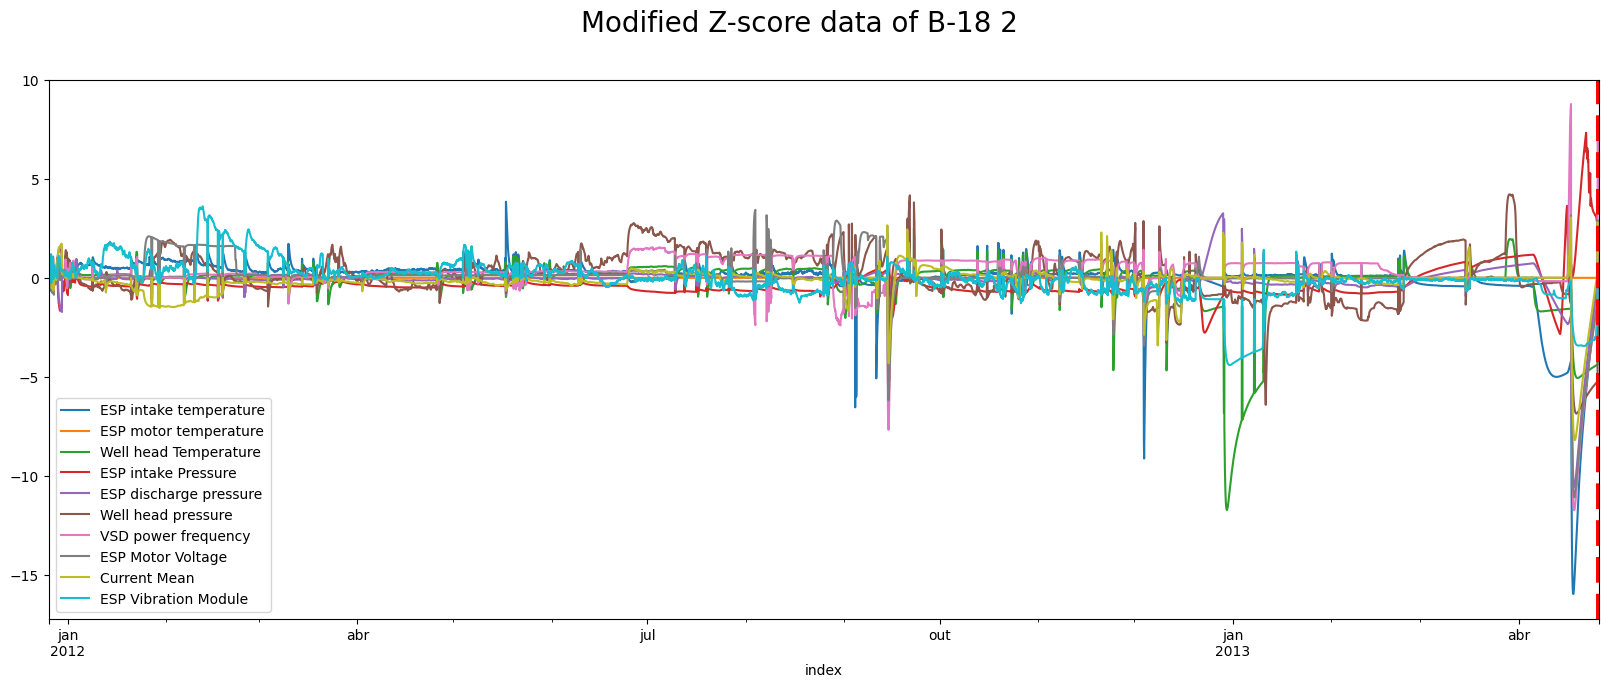

In [27]:
li.ZScorePlot(totalData,pump,Headers)
plt.savefig("../imagens_gerais/Zscore.jpg", bbox_inches='tight')


In [21]:
x = entireData.loc[entireData["Well_down"]==0][Headers]

Z = (x - x.mean())/x.std()

axes = Z.hist(bins=100,figsize=(20,20),density=True)

i = 0
measures = ["ºC","ºC","ºC","bar","bar","bar","Hz","V","A","g","g","-"]

for ax in axes.flatten():
    ax.set_title(li.Traducao(ax.get_title()))
    ax.set_xlabel("Valores [-]" )  # Define a legenda com o nome da coluna
    ax.set_ylabel("Contagem")
    ax.set_xlim([-6,6])
    i += 1


plt.suptitle("Histogramas dos dados originais",fontsize=20)
plt.tight_layout(pad=1.6)
plt.savefig("../imagens_gerais/Z-hist.jpg")
plt.close()

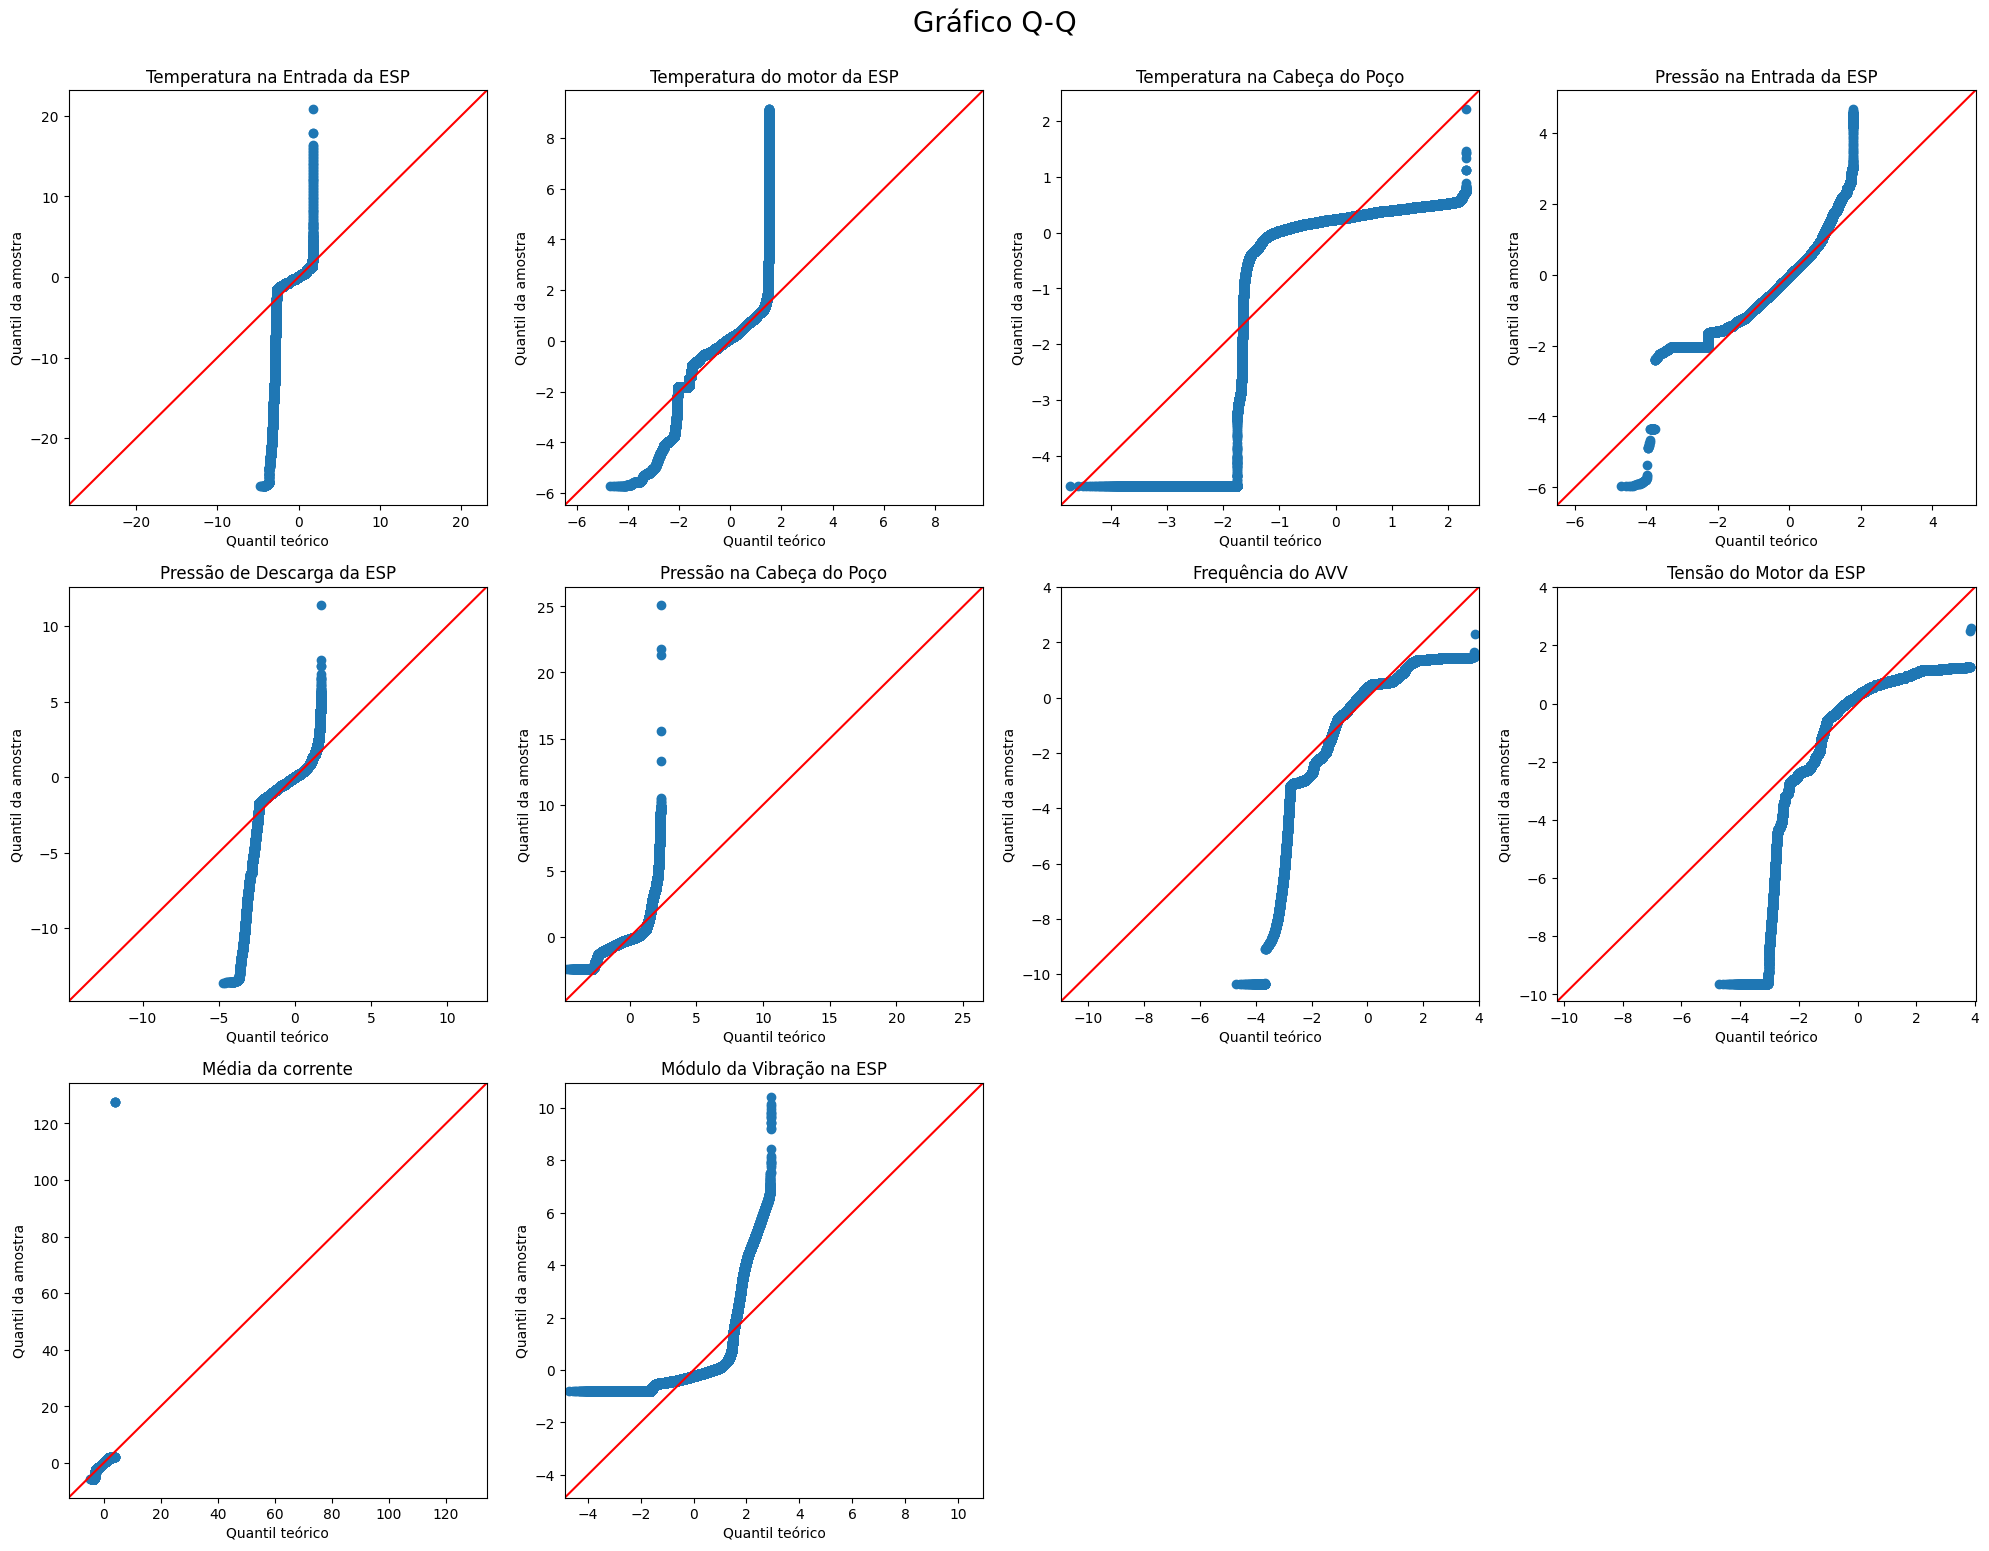

In [29]:
fig, axs = li.QQPlots(Z,Headers,lineType="45",english=False, titleFontsize=20,ydist=1)
fig.savefig("../imagens_gerais/QQplot_pt")

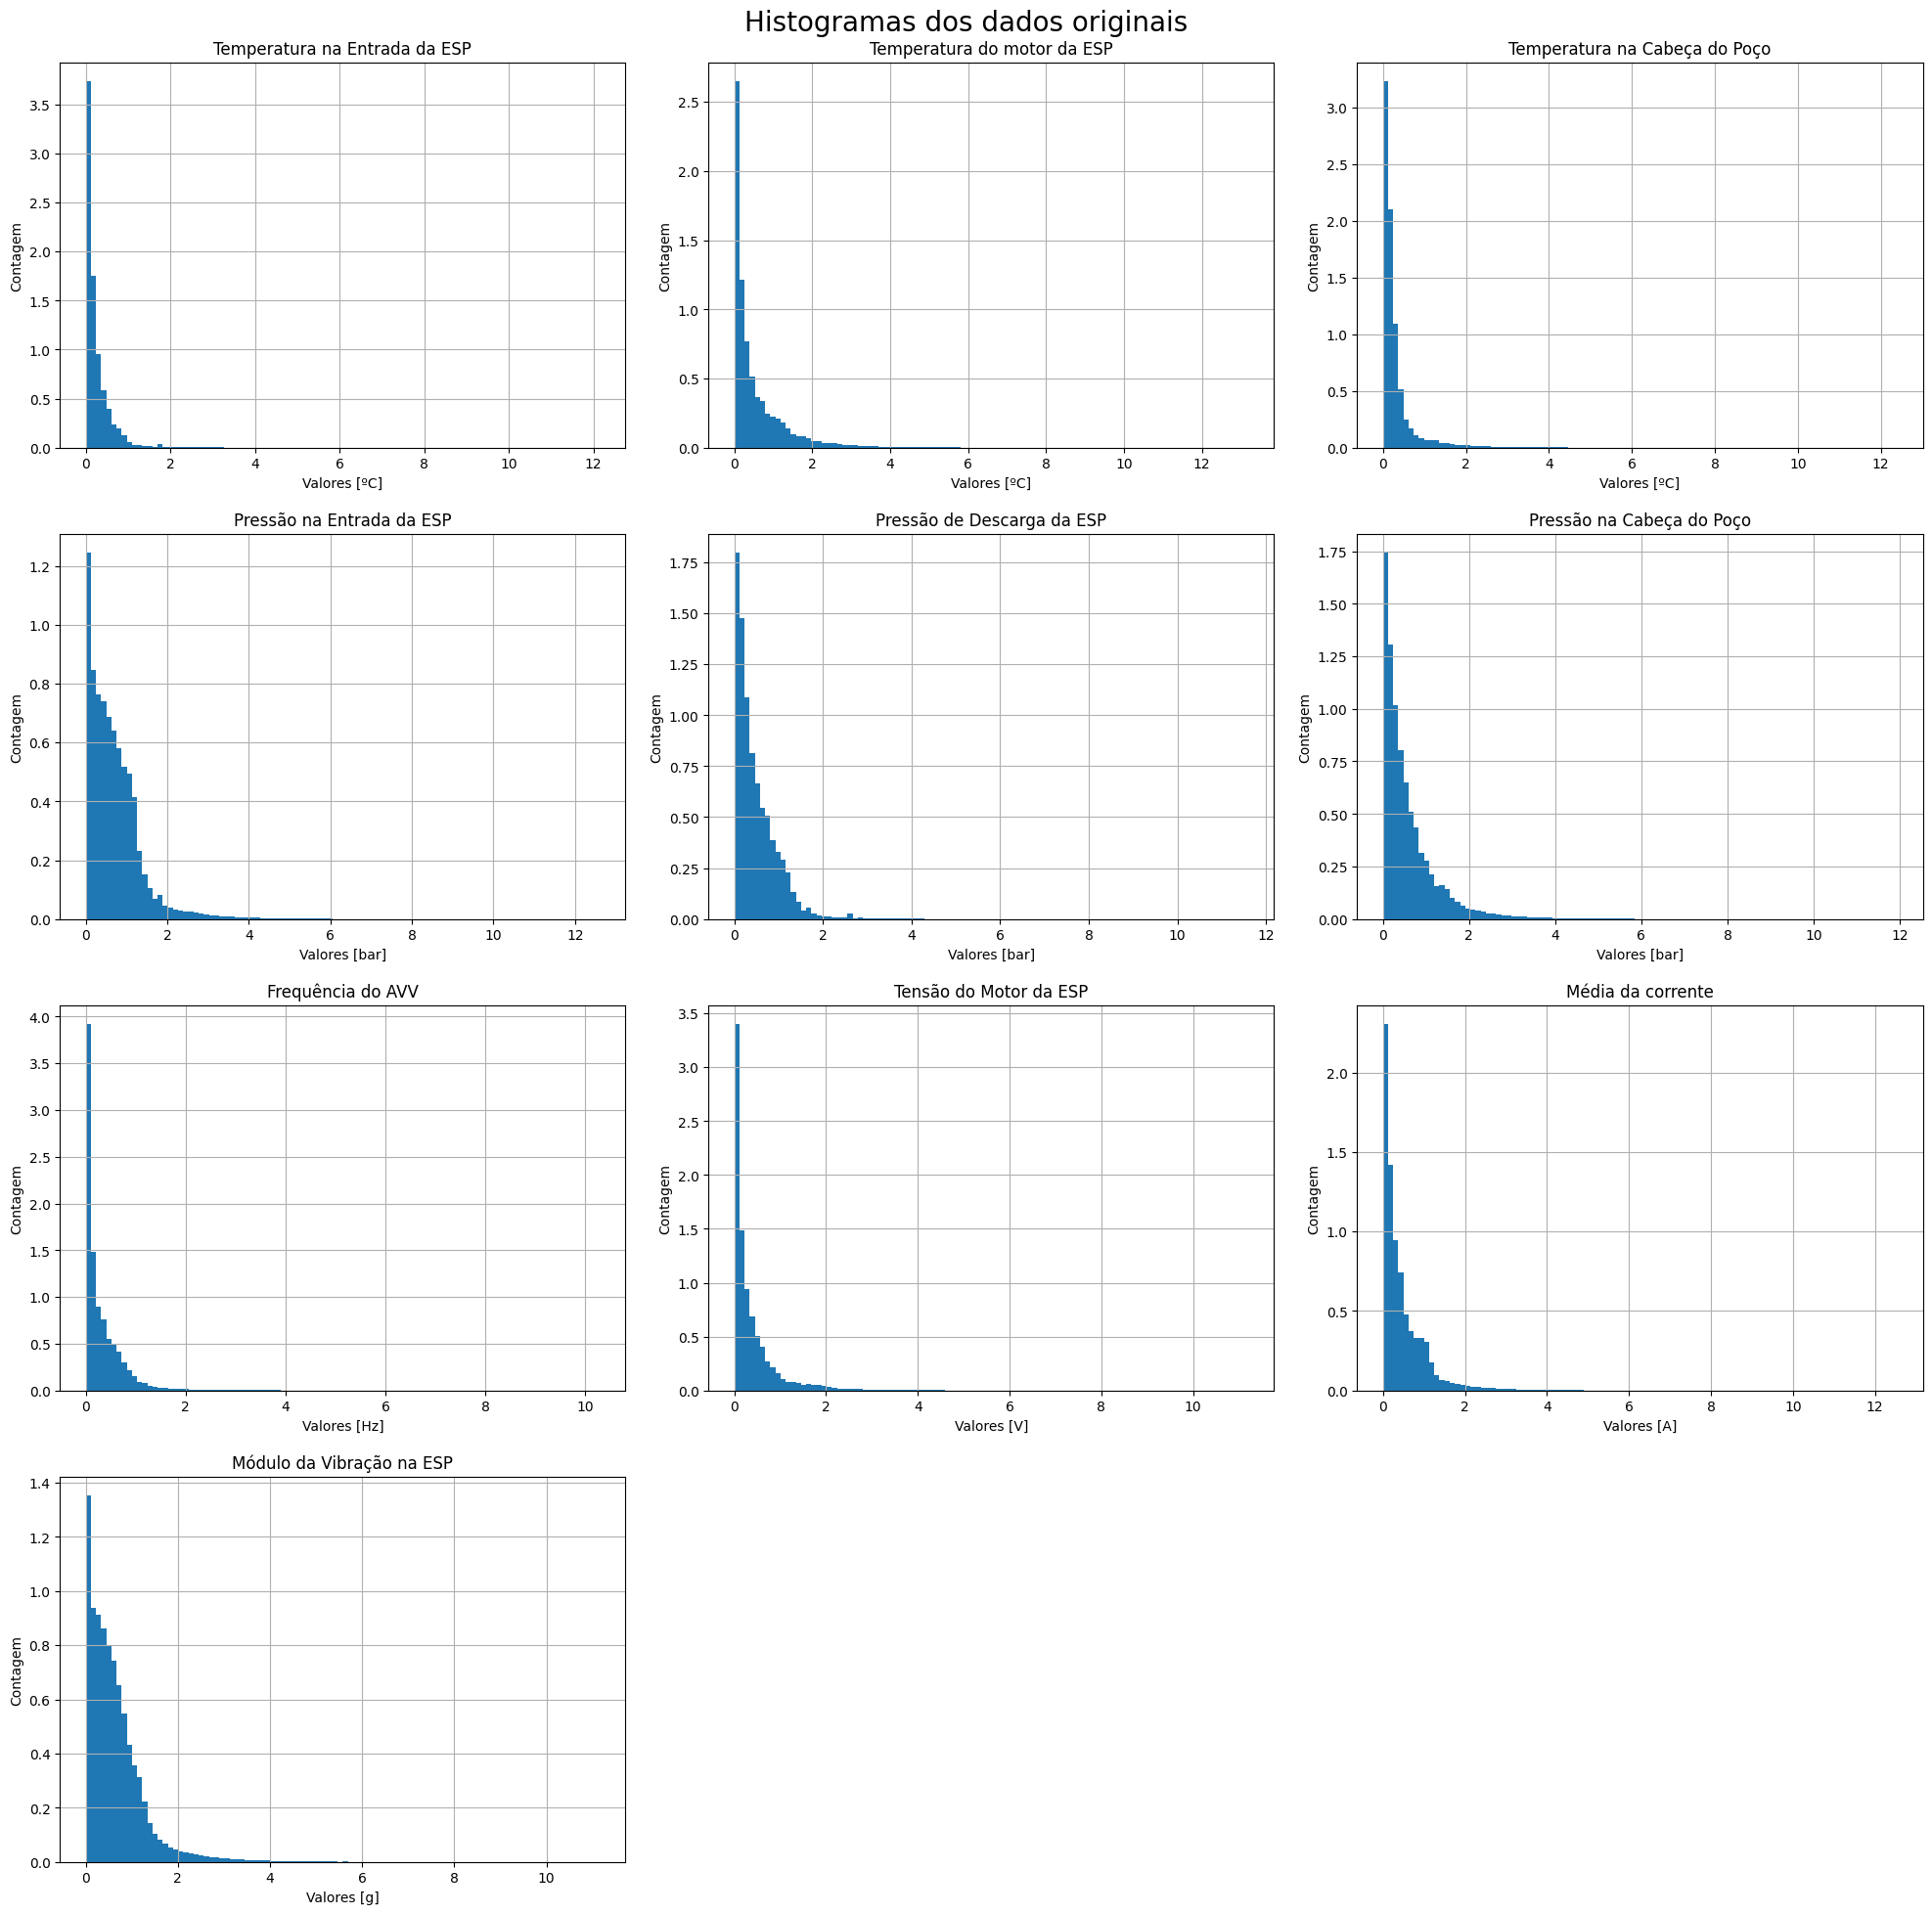

In [33]:
x = totalData.loc[totalData["Well_down"]==0][Headers].apply(np.log1p).abs()

axes = x.hist(bins=100,figsize=(20,20),density=True)

i = 0
measures = ["ºC","ºC","ºC","bar","bar","bar","Hz","V","A","g","g","-"]


for ax in axes.flatten():
    ax.set_title(li.Traducao(ax.get_title()))
    ax.set_xlabel("Valores [" +measures[i]+"]" )  # Define a legenda com o nome da coluna
    ax.set_ylabel("Contagem")
    #ax.set_xlim([-6,6])
    i += 1


plt.suptitle("Histogramas dos dados originais",fontsize=20)
plt.tight_layout(pad=1.6)
#plt.savefig("../imagens_gerais/Z-hist.jpg")